In [1]:
import torch
import matplotlib.pyplot as plt
from typing import Tuple 
import random
import numpy as np
import os
import torchvision.transforms as T
import matplotlib.pyplot as plt
import utils
from torchvision.datasets import OxfordIIITPet
from torchvision.datasets.vision import StandardTransform
from torch.utils.data import DataLoader
from tqdm import tqdm

In [2]:
class PILToTensor_for_targets:

    def __call__(self,  target):
        target = torch.as_tensor(np.array(target), dtype=torch.int64)
        # to make a binary mask, set gray(2) to 0 and black and white pet to 1
        target[(target == 1) | (target == 3)] = 1
        target[target == 2] = 0
        #target = scipy.ndimage.median_filter(target, size=(3,3))
        target = target[None, :, :]
        return target



In [3]:
# transform like preprocess required by the network
tf_rgb = T.Compose([
    T.ToTensor(),
    T.Resize(256),
    T.CenterCrop(256),
    #T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

tf_gray = T.Compose([
    T.Resize(256),
    T.CenterCrop(256),
    PILToTensor_for_targets(),
])


In [4]:
train_dataset = OxfordIIITPet(root = "dataset", split="trainval", target_types="segmentation", 
                               transform=tf_rgb, target_transform=tf_gray, download=True)

gt_mask = []
for img in tqdm(train_dataset):
    gt_mask.append(img[1])
print(len(train_dataset))

100%|██████████| 3680/3680 [00:24<00:00, 151.54it/s]

3680


In [5]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(0)

# DataLoader(
#     train_dataset,
#     batch_size=batch_size,
#     num_workers=num_workers,
#     generator=g,
#     worker_init_fn=seed_worker,
# )

In [6]:

def distance_field_point(xy: Tuple[int, int], y: torch.Tensor):
    """ 
    x is in form x[0] = x_center, x[1] = y_center, x[2] = length, x[3] = width.
    This Function computes the distance field according to:
    C_rect = (|p_x| - length)^2_+ + (|p_y| - width)^2_+
    _+ meanng max(0, x)
    """
    
    axis_x = torch.linspace(start=0, end=y.shape[0]-1, steps = y.shape[0])
    axis_y = torch.linspace(start=0, end=y.shape[1]-1, steps = y.shape[1])

    grid_x, grid_y = torch.meshgrid(axis_x, axis_y, indexing="ij")

    c_field_distance = torch.sqrt((grid_x - xy[0]) ** 2 + (grid_y - xy[1])**2)


    return c_field_distance
    
distance_field_point([0,0], torch.zeros([256, 256]))

tensor([[  0.0000,   1.0000,   2.0000,  ..., 253.0000, 254.0000, 255.0000],
        [  1.0000,   1.4142,   2.2361,  ..., 253.0020, 254.0020, 255.0020],
        [  2.0000,   2.2361,   2.8284,  ..., 253.0079, 254.0079, 255.0078],
        ...,
        [253.0000, 253.0020, 253.0079,  ..., 357.7960, 358.5038, 359.2130],
        [254.0000, 254.0020, 254.0079,  ..., 358.5038, 359.2102, 359.9181],
        [255.0000, 255.0020, 255.0078,  ..., 359.2130, 359.9181, 360.6245]])

In [7]:
dist_field = torch.zeros([256,256])
print(len(gt_mask))
for img in gt_mask:
    min_field = torch.ones(size=[256, 256])
    # multiply so in the 256 size array 362 is the biggest array
    min_field = min_field * 400
    img = torch.squeeze(img, dim=0)
    print(img.shape)
    for x in tqdm(range(img.shape[0])):
        for y in range(img.shape[1]):
            if img[x,y] == 1:
                dist_field = distance_field_point([x,y], img)
                min_field = torch.minimum(min_field, dist_field)
    break

3680
torch.Size([256, 256])


100%|██████████| 256/256 [00:05<00:00, 46.86it/s]


tensor([[96.3328, 95.6713, 95.0158,  ..., 33.5410, 34.4384, 35.3412],
        [95.5877, 94.9210, 94.2603,  ..., 33.1059, 34.0147, 34.9285],
        [94.8472, 94.1754, 93.5094,  ..., 32.6956, 33.6155, 34.5398],
        ...,
        [47.5079, 46.7547, 46.0109,  ..., 90.6973, 91.5260, 92.3580],
        [48.1664, 47.4236, 46.6905,  ..., 91.2634, 92.0869, 92.9139],
        [48.8365, 48.1041, 47.3814,  ..., 91.8368, 92.6553, 93.4773]])


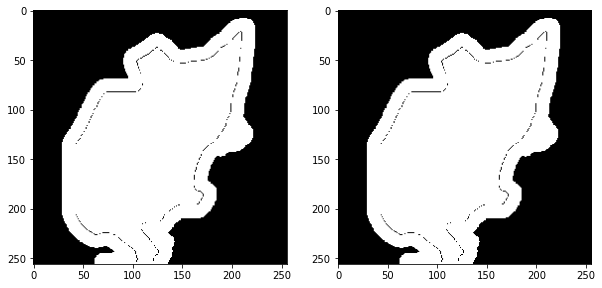

In [9]:
print(min_field)
_, ax = plt.subplots(1,2, figsize=(10,10))
ax[0].imshow(torch.squeeze(gt_mask[0]), cmap="gray")
ax[1].imshow(min_field == 0, cmap="gray")
plt.show()